# SiLVERScore paper figure reproduction

This notebook reproduces the core analysis figures/tables from:

- Imai et al., 2025 (RANLP): https://aclanthology.org/2025.ranlp-1.54/

Included:

1. **Figure 2 style**: KDE plots for correct-vs-random alignment (PHOENIX-14T)
2. **Figure 3 style**: KDE plots for reordered hypotheses (PHOENIX-14T)
3. **Table 1 metrics**: overlap (%) and ROC AUC for PHOENIX-14T and CSL-Daily

> Note: Figure 4 (prosody) requires prosody-annotation files not currently in this repo.


In [9]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_auc_score

sns.set_theme(style="whitegrid")

# Preferred data locations (first existing path is used):
# - ./paper_data            (bundled with this repo)
# - ../signscore            (monorepo/workspace fallback)
CANDIDATES = [
    Path.cwd() / "paper_data",
    Path.cwd().parent / "signscore",
    Path.cwd().parent.parent / "signscore",
]
DATA_ROOT = next((p for p in CANDIDATES if (p / "sign_score_data.csv").exists()), None)
if DATA_ROOT is None:
    raise FileNotFoundError(
        "Could not find paper CSV files. Place them in ../signscore or notebooks/paper_data."
    )

OUT_DIR = Path.cwd() / "figures"
OUT_DIR.mkdir(parents=True, exist_ok=True)

print(f"Using DATA_ROOT: {DATA_ROOT}")
print(f"Saving outputs to: {OUT_DIR}")

Using DATA_ROOT: /Users/merterm/Documents/SLRT/signscore
Saving outputs to: /Users/merterm/Documents/SLRT/silverscore/notebooks/figures


In [10]:
ph_bt = pd.read_csv(DATA_ROOT / "bt_score_data.csv")
ph_sign = pd.read_csv(DATA_ROOT / "sign_score_data.csv")
csl_bt = pd.read_csv(DATA_ROOT / "csl_bt_score_data.csv")
csl_sign = pd.read_csv(DATA_ROOT / "csl_sign_score_data.csv")

ph_bt_re = pd.read_csv(DATA_ROOT / "bt_score_reorder_data.csv")
ph_sign_re = pd.read_csv(DATA_ROOT / "signscore_reorder_data.csv")
csl_bt_re = pd.read_csv(DATA_ROOT / "csl_bt_score_reorder_data.csv")
csl_sign_re = pd.read_csv(DATA_ROOT / "csl_signscore_reorder_data.csv")

def minmax_pair(a, b):
    a = pd.Series(a).dropna().astype(float)
    b = pd.Series(b).dropna().astype(float)
    lo = min(a.min(), b.min())
    hi = max(a.max(), b.max())
    if hi == lo:
        return np.zeros(len(a)), np.zeros(len(b))
    return (a - lo) / (hi - lo), (b - lo) / (hi - lo)

def overlap_pct(a_norm, b_norm, bins=50):
    h1, edges = np.histogram(a_norm, bins=bins, range=(0, 1), density=True)
    h2, _ = np.histogram(b_norm, bins=bins, range=(0, 1), density=True)
    return 100.0 * float(np.sum(np.minimum(h1, h2) * np.diff(edges)))

def auc_score(a, b):
    y = np.concatenate([np.ones(len(a)), np.zeros(len(b))])
    s = np.concatenate([np.asarray(a, dtype=float), np.asarray(b, dtype=float)])
    return float(roc_auc_score(y, s))

def summary_table(metric_pairs):
    """
    Paper §4.1 style (correct vs random):
    - overlap on joint min-max normalized scores
    - AUC on raw scores
    """
    rows = []
    skipped = []
    for metric, (a, b) in metric_pairs.items():
        a_clean = pd.Series(a).dropna().astype(float)
        b_clean = pd.Series(b).dropna().astype(float)

        # Skip metrics that are undefined for a dataset split (e.g., CSL BLEU-4).
        if len(a_clean) == 0 or len(b_clean) == 0:
            skipped.append(metric)
            continue

        a_norm, b_norm = minmax_pair(a_clean, b_clean)
        rows.append(
            {
                "metric": metric,
                "overlap_pct": overlap_pct(a_norm, b_norm),
                "auc": auc_score(a_clean, b_clean),
            }
        )

    if skipped:
        print(f"Skipped undefined metrics: {skipped}")

    return pd.DataFrame(rows).set_index("metric")


def minmax_single(x):
    x = pd.Series(x).dropna().astype(float)
    if len(x) == 0:
        return x
    lo, hi = x.min(), x.max()
    if hi == lo:
        return pd.Series(np.zeros(len(x)))
    return (x - lo) / (hi - lo)


def overlap_independent(a_norm, b_norm, bins=50):
    """
    Matches signscore/reorder_plot.ipynb logic:
    - histograms on independently normalized series
    - overlap = sum(min(hist_a, hist_b)) * (1 / bins)
    """
    h1, _ = np.histogram(a_norm, bins=bins, density=True)
    h2, _ = np.histogram(b_norm, bins=bins, density=True)
    return 100.0 * float(np.sum(np.minimum(h1, h2)) * (1 / bins))


def summary_table_reordered(metric_pairs):
    """
    Paper §4.2 style (original vs reordered), aligned with signscore/reorder_plot.ipynb:
    - independently min-max normalize original/reordered
    - overlap on independent-normalized series
    - AUC on independent-normalized series
    """
    rows = []
    skipped = []
    for metric, (a, b) in metric_pairs.items():
        a_norm = minmax_single(a)
        b_norm = minmax_single(b)

        if len(a_norm) == 0 or len(b_norm) == 0:
            skipped.append(metric)
            continue

        rows.append(
            {
                "metric": metric,
                "overlap_pct": overlap_independent(a_norm, b_norm),
                "auc": auc_score(a_norm, b_norm),
            }
        )

    if skipped:
        print(f"Skipped undefined metrics: {skipped}")

    return pd.DataFrame(rows).set_index("metric")

In [11]:
ph_correct = {
    "BLEU-1": (ph_bt["same_index_bleu1"], ph_bt["different_index_bleu1"]),
    "BLEU-2": (ph_bt["same_index_bleu2"], ph_bt["different_index_bleu2"]),
    "BLEU-3": (ph_bt["same_index_bleu3"], ph_bt["different_index_bleu3"]),
    "BLEU-4": (ph_bt["same_index_bleu4"], ph_bt["different_index_bleu4"]),
    "ROUGE": (ph_bt["same_index_rouge"], ph_bt["different_index_rouge"]),
    "BERTScore": (ph_bt["same_index_bert"], ph_bt["different_index_bert"]),
    "BLEURT": (ph_bt["same_index_bleurt"], ph_bt["different_index_bleurt"]),
    "SiLVERScore": (ph_sign["same_scores_i2t"], ph_sign["different_scores_i2t"]),
}

csl_correct = {
    "BLEU-1": (csl_bt["same_index_bleu1"], csl_bt["different_index_bleu1"]),
    "BLEU-2": (csl_bt["same_index_bleu2"], csl_bt["different_index_bleu2"]),
    "BLEU-3": (csl_bt["same_index_bleu3"], csl_bt["different_index_bleu3"]),
    "ROUGE": (csl_bt["same_index_rouge"], csl_bt["different_index_rouge"]),
    "BERTScore": (csl_bt["same_index_bert"], csl_bt["different_index_bert"]),
    "BLEURT": (csl_bt["same_index_bleurt"], csl_bt["different_index_bleurt"]),
    "SiLVERScore": (csl_sign["same_scores_i2t"], csl_sign["different_scores_i2t"]),
}

ph_reordered = {
    "BLEU-1": (ph_bt_re["original_bleu1"], ph_bt_re["reordered_bleu1"]),
    "BLEU-2": (ph_bt_re["original_bleu2"], ph_bt_re["reordered_bleu2"]),
    "BLEU-3": (ph_bt_re["original_bleu3"], ph_bt_re["reordered_bleu3"]),
    "BLEU-4": (ph_bt_re["original_bleu4"], ph_bt_re["reordered_bleu4"]),
    "ROUGE": (ph_bt_re["original_rouge"], ph_bt_re["reordered_rouge"]),
    "BERTScore": (ph_bt_re["original_bert"], ph_bt_re["reordered_bert"]),
    "BLEURT": (ph_bt_re["original_bleurt"], ph_bt_re["reordered_bleurt"]),
    "SiLVERScore": (ph_sign_re["original_i2t"], ph_sign_re["reordered_i2t"]),
}

csl_reordered = {
    "BLEU-1": (csl_bt_re["original_bleu1"], csl_bt_re["reordered_bleu1"]),
    "BLEU-2": (csl_bt_re["original_bleu2"], csl_bt_re["reordered_bleu2"]),
    "BLEU-3": (csl_bt_re["original_bleu3"], csl_bt_re["reordered_bleu3"]),
    "BLEU-4": (csl_bt_re["original_bleu4"], csl_bt_re["reordered_bleu4"]),
    "ROUGE": (csl_bt_re["original_rouge"], csl_bt_re["reordered_rouge"]),
    "BERTScore": (csl_bt_re["original_bert"], csl_bt_re["reordered_bert"]),
    "BLEURT": (csl_bt_re["original_bleurt"], csl_bt_re["reordered_bleurt"]),
    "SiLVERScore": (csl_sign_re["original_i2t"], csl_sign_re["reordered_i2t"]),
}

print("Table 1 (Correct vs Random)")
display(pd.concat({"PHOENIX-14T": summary_table(ph_correct), "CSL-Daily": summary_table(csl_correct)}, axis=1).round(4))

print("Table 1 (Original vs Reordered)")
display(pd.concat({"PHOENIX-14T": summary_table_reordered(ph_reordered), "CSL-Daily": summary_table_reordered(csl_reordered)}, axis=1).round(4))

Table 1 (Correct vs Random)


PHOENIX-14T           CSL-Daily        
            overlap_pct     auc overlap_pct     auc
metric                                             
BLEU-1          19.7819  0.9536      6.0374  0.9951
BLEU-2          24.2991  0.9017      5.2721  0.9863
BLEU-3          38.6293  0.8096     23.8946  0.8818
BLEU-4          55.4517  0.7234         NaN     NaN
ROUGE           19.9377  0.9506      6.1224  0.9944
BERTScore       14.1745  0.9735      9.2687  0.9895
BLEURT          21.6511  0.9538     11.9048  0.9836
SiLVERScore      6.8536  0.9934      7.3980  0.9930

Table 1 (Original vs Reordered)


PHOENIX-14T           CSL-Daily        
            overlap_pct     auc overlap_pct     auc
metric                                             
BLEU-1          64.4860  0.6529     69.2829  0.4570
BLEU-2          71.4953  0.6336     69.5991  0.4909
BLEU-3          66.9782  0.6469     76.4289  0.5208
BLEU-4          69.4704  0.6316     83.9103  0.5384
ROUGE           67.4455  0.6698     70.0537  0.5459
BERTScore       78.1931  0.5521     75.1820  0.5103
BLEURT          81.3084  0.4679     70.2397  0.3993
SiLVERScore     83.4891  0.5951     87.8401  0.4572

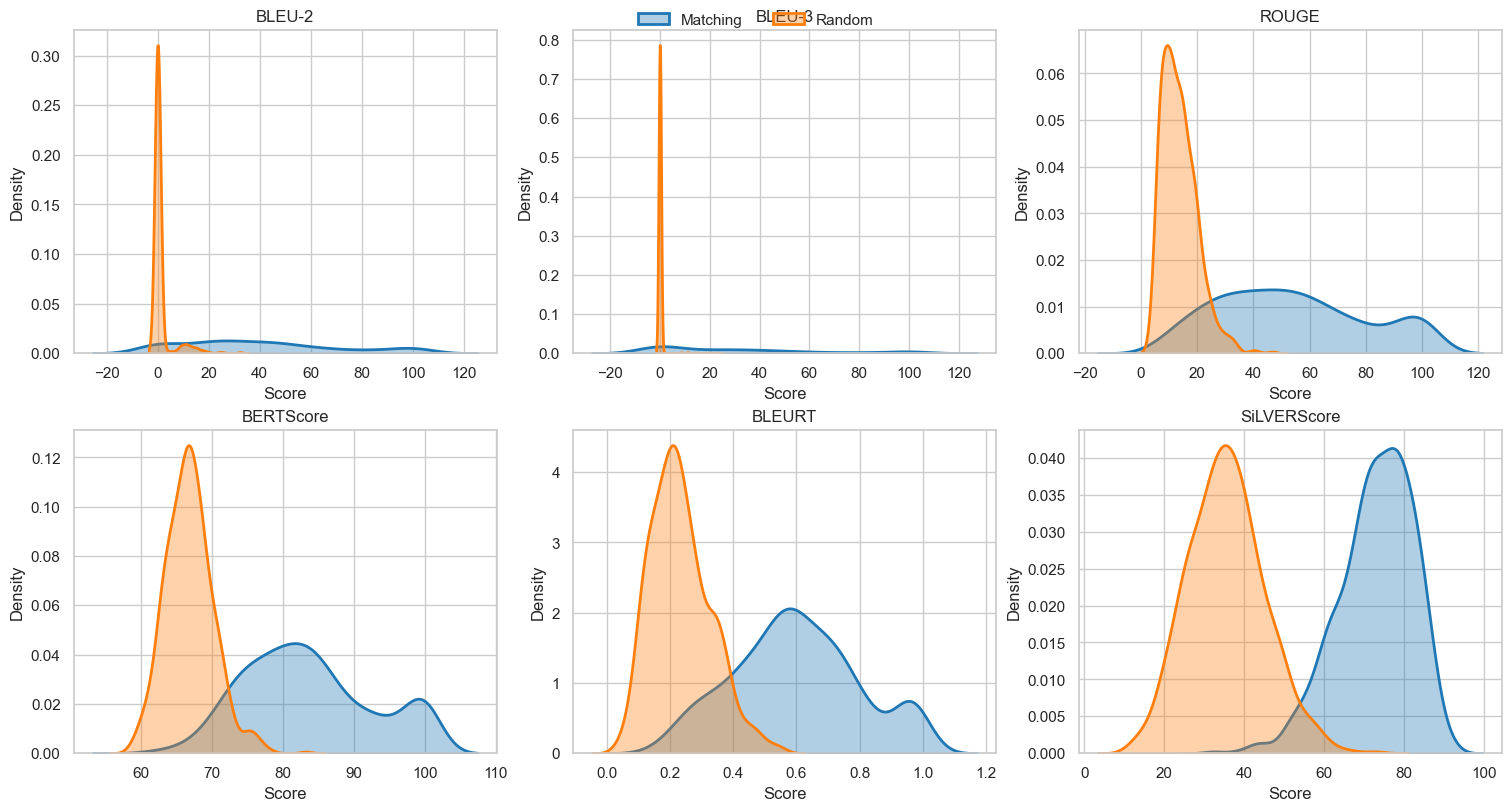

Saved /Users/merterm/Documents/SLRT/silverscore/notebooks/figures/paper_figure2_kde_correct_vs_random_phoenix.png


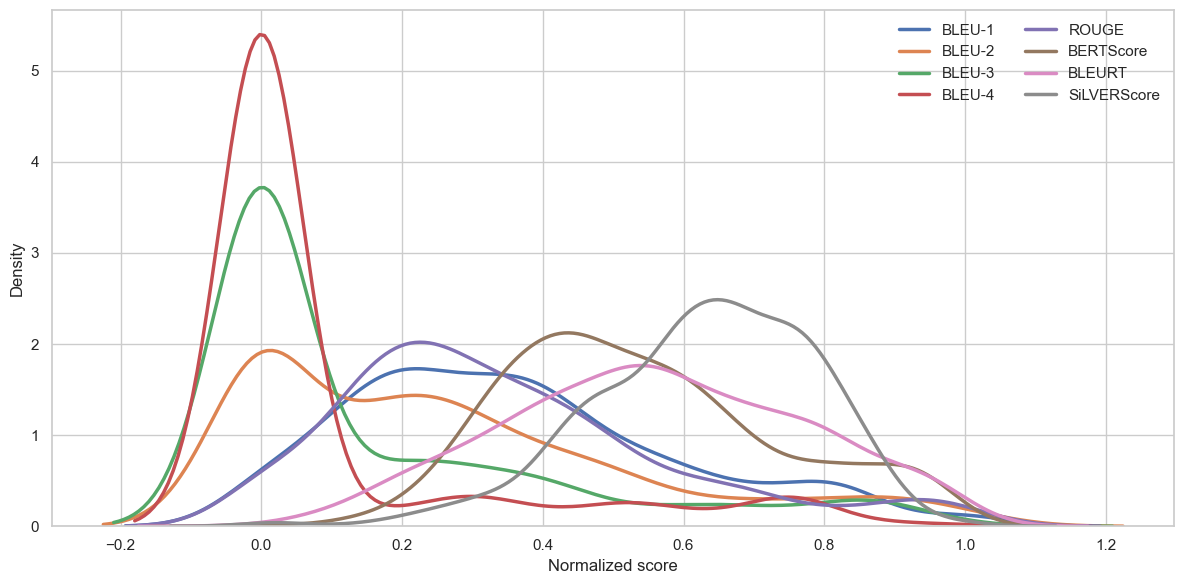

Saved /Users/merterm/Documents/SLRT/silverscore/notebooks/figures/paper_figure3_kde_reordered_phoenix.png


In [12]:
# Figure 2 style (PHOENIX-14T): KDE for matching vs random
fig2_metrics = ["BLEU-2", "BLEU-3", "ROUGE", "BERTScore", "BLEURT", "SiLVERScore"]
fig, axes = plt.subplots(2, 3, figsize=(15, 8), constrained_layout=True)

for ax, metric in zip(axes.flatten(), fig2_metrics):
    a, b = ph_correct[metric]
    sns.kdeplot(pd.Series(a).dropna(), ax=ax, fill=True, alpha=0.35, color="#1f77b4", linewidth=2, label="Matching", warn_singular=False)
    sns.kdeplot(pd.Series(b).dropna(), ax=ax, fill=True, alpha=0.35, color="#ff7f0e", linewidth=2, label="Random", warn_singular=False)
    ax.set_title(metric)
    ax.set_xlabel("Score")
    ax.set_ylabel("Density")

handles, labels = axes.flatten()[0].get_legend_handles_labels()
for ax in axes.flatten():
    if ax.legend_ is not None:
        ax.legend_.remove()
fig.legend(handles, labels, loc="upper center", ncol=2, frameon=False)

fig2_path = OUT_DIR / "paper_figure2_kde_correct_vs_random_phoenix.png"
plt.savefig(fig2_path, dpi=300, bbox_inches="tight")
plt.show()
print("Saved", fig2_path)

# Figure 3 style (PHOENIX-14T): KDE for reordered hypotheses (normalized)
plt.figure(figsize=(12, 6))
for metric, (_, reordered) in ph_reordered.items():
    s = pd.Series(reordered).dropna().astype(float)
    if s.nunique() <= 1:
        continue
    s_norm = (s - s.min()) / (s.max() - s.min())
    sns.kdeplot(s_norm, linewidth=2.5, label=metric, warn_singular=False)

plt.xlabel("Normalized score")
plt.ylabel("Density")
plt.legend(ncol=2, frameon=False)
plt.tight_layout()

fig3_path = OUT_DIR / "paper_figure3_kde_reordered_phoenix.png"
plt.savefig(fig3_path, dpi=300, bbox_inches="tight")
plt.show()
print("Saved", fig3_path)